In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
## Read google sheet with OHSU occupancy data

sheet_name = 'ohsu_occupancy'
sheet_id = '1ZHjiYYiEg_VVAuJrqkOXhgMiKWd_6EvGn8VDha7qdMw'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

In [ ]:
## Load into dataframe

data = pd.read_csv(url)
data

,month_start,days,occupancy,available_beds,licensed_beds,occupancy_rate
0,2007-01-01,31,11585,499,560,0.6673
1,2007-02-01,28,10662,499,560,0.6800
2,2007-03-01,31,12523,499,509,0.7936
3,2007-04-01,30,11887,499,509,0.7785
4,2007-05-01,31,11990,499,509,0.7599
...,...,...,...,...,...,...
211,2024-08-01,31,15326,562,576,0.8583
212,2024-09-01,30,14893,562,576,0.8619
213,2024-10-01,31,15406,562,576,0.8628
214,2024-11-01,30,14890,562,576,0.8617


In [5]:
## Data inspection

data.info()
data.describe()
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   month_start     216 non-null    object 
 1   days            216 non-null    int64  
 2   occupancy       216 non-null    int64  
 3   available_beds  216 non-null    int64  
 4   licensed_beds   216 non-null    int64  
 5   occupancy_rate  216 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 10.3+ KB


month_start       0
days              0
occupancy         0
available_beds    0
licensed_beds     0
occupancy_rate    0
dtype: int64

In [6]:
## Convert month_start to datetime

data['month_start'] = pd.to_datetime(data['month_start'])
data = data.sort_values('month_start')

Text(0.5, 1.0, 'OHSU Monthly Occupancy (2007–2024)')

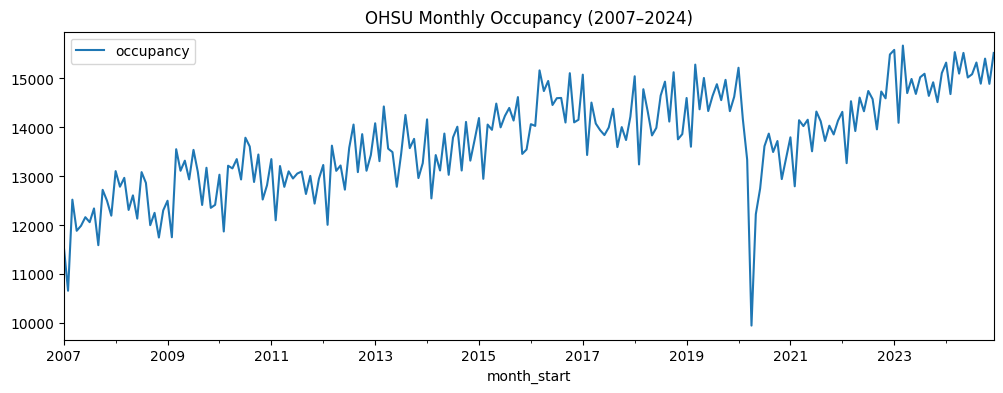

In [24]:
## Plot overall occupancy

data.plot(x='month_start', y='occupancy', figsize=(12,4))
plt.title("OHSU Monthly Occupancy (2007–2024)")

Text(0.5, 1.0, 'OHSU Monthly Occupancy Rate (2007–2024)')

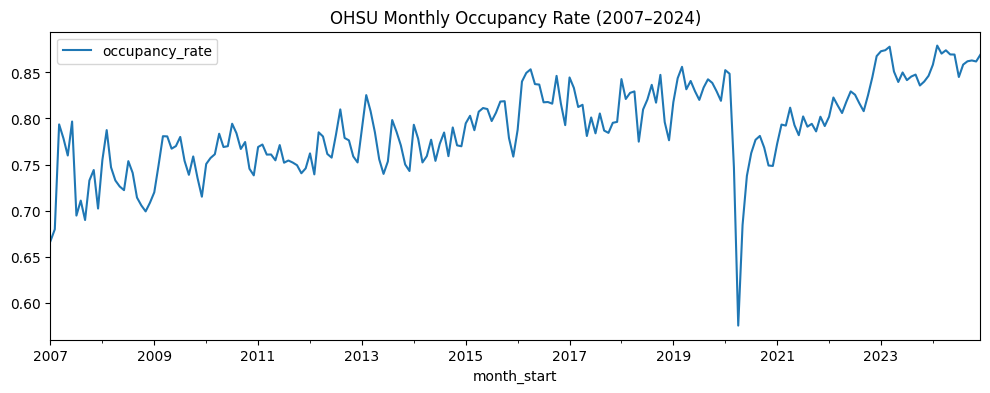

In [25]:
## Plot occupancy rate

data.plot(x='month_start', y='occupancy_rate', figsize=(12,4))
plt.title("OHSU Monthly Occupancy Rate (2007–2024)")

In [9]:
## Add year and month

data['year'] = data['month_start'].dt.year
data['month'] = data['month_start'].dt.month

(10000.0, 15000.0)

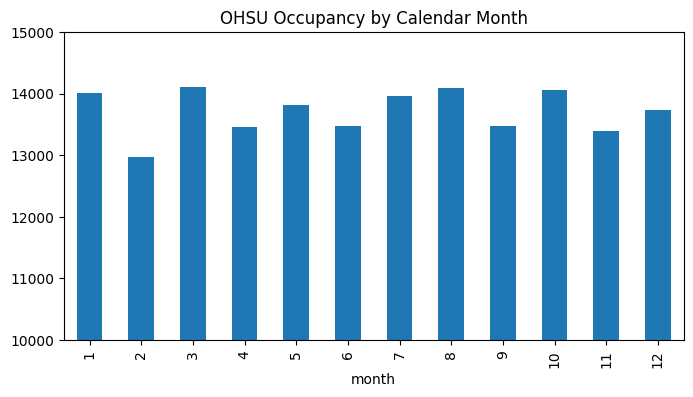

In [ ]:
## Monthly seasonality of total occupancy
## Adjusted y-axis so pattern is more visible

data.groupby('month')['occupancy'].mean().plot(kind='bar', figsize=(8,4))
plt.title("OHSU Occupancy by Calendar Month")
plt.ylim(10000, 15000)

(0.7, 0.82)

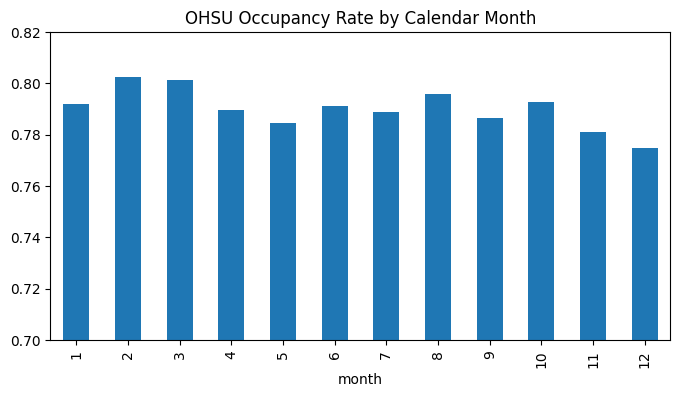

In [42]:
## Monthly seasonality of occupancy rate
## Adjusted y-axis so pattern is more visible

data.groupby('month')['occupancy_rate'].mean().plot(kind='bar', figsize=(8,4))
plt.title("OHSU Occupancy Rate by Calendar Month")
plt.ylim(0.7, 0.82)

In [14]:
## Check correlations

data[['occupancy', 'available_beds', 'licensed_beds', 'occupancy_rate']].corr()

,occupancy,available_beds,licensed_beds,occupancy_rate
occupancy,1.000000,0.733163,0.585974,0.895957
available_beds,0.733163,1.000000,0.747422,0.650140
licensed_beds,0.585974,0.747422,1.000000,0.401072
occupancy_rate,0.895957,0.650140,0.401072,1.000000


Text(0.5, 1.0, 'OHSU Monthly Occupancy Rate (2007–2024)')

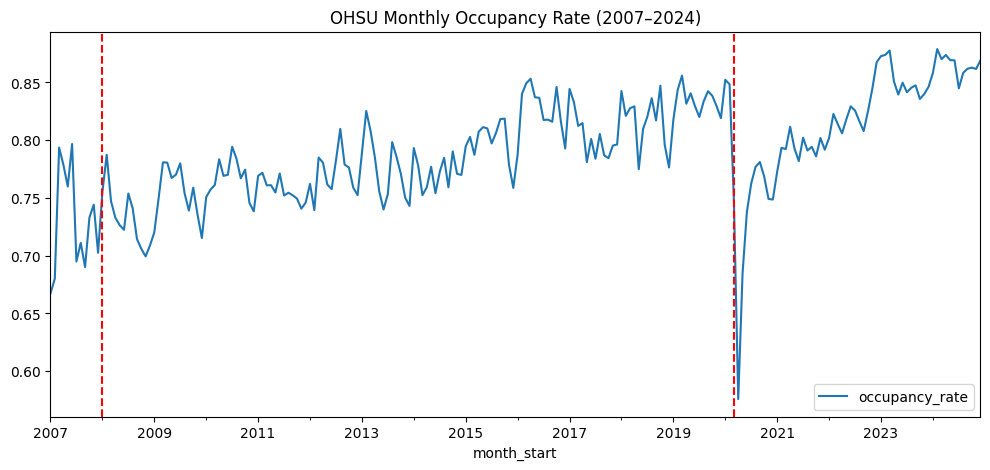

In [28]:
data.plot(x='month_start', y='occupancy_rate', figsize=(12,5))
plt.axvline(pd.Timestamp('2008-01-01'), color='red', linestyle='--')  # 2008 financial recession
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--')  # 2020 COVID
plt.title("OHSU Monthly Occupancy Rate (2007–2024)")

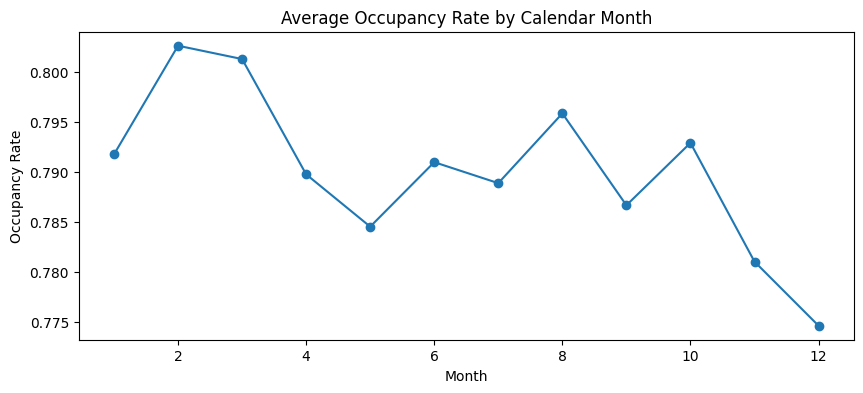

In [ ]:
## Which months are consistently busiest? -- January, February, March, August, October
## Are there predictable slow periods? -- November and December
## Do winter respiratory seasons show clear spikes? -- Yes, fall thru spring

monthly_avg = data.groupby('month')['occupancy_rate'].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(marker='o')
plt.title("Average Occupancy Rate by Calendar Month")
plt.ylabel("Occupancy Rate")
plt.xlabel("Month")
plt.show()

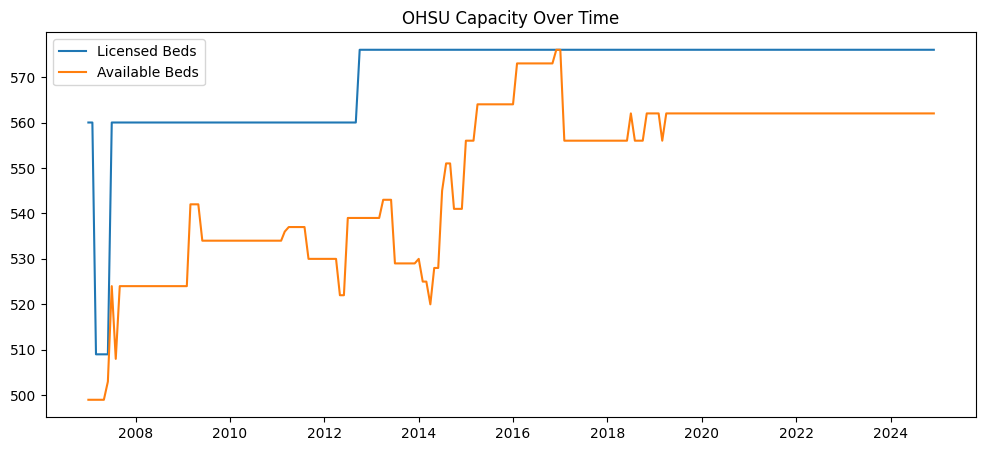

In [30]:
## Show capacity constraints
## Added beds in 2013. Renovation? New unit?
## What caused temporary bed decrease in 2007?

plt.figure(figsize=(12,5))
plt.plot(data['month_start'], data['licensed_beds'], label="Licensed Beds")
plt.plot(data['month_start'], data['available_beds'], label="Available Beds")
plt.legend()
plt.title("OHSU Capacity Over Time")
plt.show()

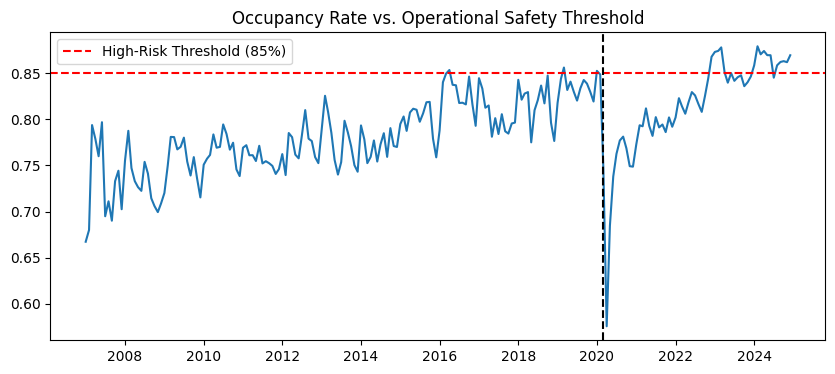

In [ ]:
## Where demand exceeds operational capacity
## Operational safety threshold is met in 2016, remains close to risk until COVID
## After COVID, occupancy remained depressed from canceled surgeries until 2022
## Pre-pandemic levels return around 2023, straining operational safety more than before
## Staffing shortages?

plt.figure(figsize=(10,4))
plt.plot(data['month_start'], data['occupancy_rate'])
plt.axhline(0.85, color='red', linestyle='--', label='High-Risk Threshold (85%)')
plt.axvline(pd.Timestamp("2020-03-01"), linestyle="--", color="black") ## COVID
plt.legend()
plt.title("Occupancy Rate vs. Operational Safety Threshold")
plt.show()

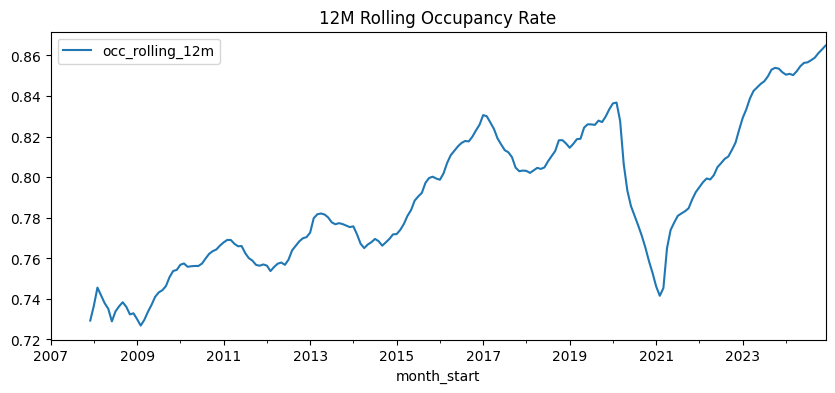

In [ ]:
## 12 month rolling average occupancy rate

data['occ_rolling_12m'] = data['occupancy_rate'].rolling(12).mean()
data.plot(x='month_start', y='occ_rolling_12m', figsize=(10,4), title='12M Rolling Occupancy Rate')

In [45]:
## Label unsafe months

unsafe = data[data['occupancy_rate'] > 0.85]
unsafe[['month_start', 'occupancy_rate']]

,month_start,occupancy_rate
111,2016-04-01,0.8532
146,2019-03-01,0.8559
156,2020-01-01,0.8523
191,2022-12-01,0.8675
192,2023-01-01,0.8728
193,2023-02-01,0.8739
194,2023-03-01,0.8777
195,2023-04-01,0.8508
204,2024-01-01,0.8582
205,2024-02-01,0.8789


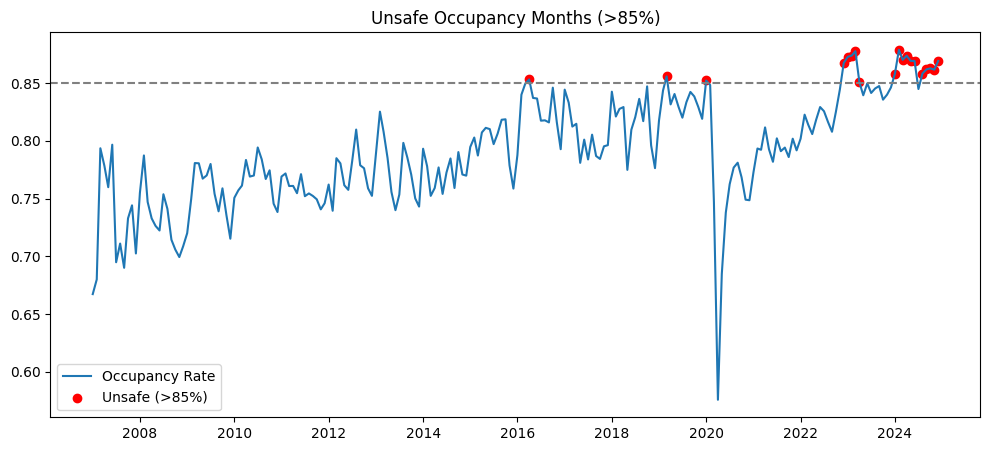

In [46]:
## Visualize unsafe months

plt.figure(figsize=(12,5))
plt.plot(data['month_start'], data['occupancy_rate'], label='Occupancy Rate')

# Highlight unsafe months in red
plt.scatter(
    unsafe['month_start'],
    unsafe['occupancy_rate'],
    color='red',
    label='Unsafe (>85%)'
)

plt.axhline(0.85, color='gray', linestyle='--')
plt.legend()
plt.title("Unsafe Occupancy Months (>85%)")
plt.show()